<a href="https://colab.research.google.com/github/desmond-lartey/Knowledge-Management-Informatics/blob/Fires/planner/examples/train_segmentation_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Train a Semantic Segmentation Model using Segmentation-Models-PyTorch

[![image](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/opengeos/geoai/blob/main/docs/examples/train_segmentation_model.ipynb)

This notebook demonstrates how to train semantic segmentation models for object detection (e.g., building detection) using the [segmentation-models-pytorch](https://smp.readthedocs.io) library. Unlike instance segmentation with Mask R-CNN, this approach treats the task as pixel-level binary classification.

## Install packages
To use the new functionality, ensure the required packages are installed.


In [1]:
 %pip install geoai-py

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.6/269.6 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.5/122.5 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 618.7/618.7 kB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 119.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 882.2/882.2 kB 71.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 75.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 113.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 605.0/605.0 kB 55.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.5/20.5 MB 121.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## Import libraries

In [2]:
import geoai

## Download sample data

We'll use the same dataset as the Mask R-CNN example for consistency.

In [3]:
train_raster_url = (
    "https://huggingface.co/datasets/giswqs/geospatial/resolve/main/naip_rgb_train.tif"
)
train_vector_url = "https://huggingface.co/datasets/giswqs/geospatial/resolve/main/naip_train_buildings.geojson"
test_raster_url = (
    "https://huggingface.co/datasets/giswqs/geospatial/resolve/main/naip_test.tif"
)

In [4]:
train_raster_path = geoai.download_file(train_raster_url)
train_vector_path = geoai.download_file(train_vector_url)
test_raster_path = geoai.download_file(test_raster_url)

## Visualize sample data

In [5]:
geoai.get_raster_info(train_raster_path)

{'driver': 'GTiff',
 'width': 2503,
 'height': 1126,
 'count': 3,
 'dtype': 'uint8',
 'crs': 'EPSG:26911',
 'transform': Affine(0.6000000000000046, 0.0, 454780.8,
        0.0, -0.6, 5278242.6),
 'bounds': BoundingBox(left=454780.8, bottom=5277567.0, right=456282.6, top=5278242.6),
 'resolution': (0.6000000000000046, 0.6),
 'nodata': None,
 'band_stats': [{'band': 1,
   'min': 12.0,
   'max': 251.0,
   'mean': 150.6730747259594,
   'std': 48.01908734374099},
  {'band': 2,
   'min': 49.0,
   'max': 251.0,
   'mean': 141.92468895229808,
   'std': 43.46595463573497},
  {'band': 3,
   'min': 53.0,
   'max': 251.0,
   'mean': 120.89909373405554,
   'std': 41.78086244480775}]}

In [6]:
geoai.view_vector_interactive(train_vector_path, tiles=train_raster_path)

In [7]:
geoai.view_raster(test_raster_path)

Map(center=[47.6464835, -117.59043650000001], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom…

## Create training data

We'll create the same training tiles as before.

In [8]:
out_folder = "buildings"
tiles = geoai.export_geotiff_tiles(
    in_raster=train_raster_path,
    out_folder=out_folder,
    in_class_data=train_vector_path,
    tile_size=512,
    stride=256,
    buffer_radius=0,
)


Raster info for naip_rgb_train.tif:
  CRS: EPSG:26911
  Dimensions: 2503 x 1126
  Resolution: (0.6000000000000046, 0.6)
  Bands: 3
  Bounds: BoundingBox(left=454780.8, bottom=5277567.0, right=456282.6, top=5278242.6)
Loaded 735 features from naip_train_buildings.geojson
Vector CRS: EPSG:4326
Reprojecting features from EPSG:4326 to EPSG:26911
Found 1 unique classes: ['building']


Generated: 36, With features: 36: 100%|██████████| 36/36 [00:07<00:00,  4.56it/s]


------- Export Summary -------
Total tiles exported: 36
Tiles with features: 36 (100.0%)
Average feature pixels per tile: 46795.0
Output saved to: buildings

------- Georeference Verification -------


## Train semantic segmentation model

Now we'll train a semantic segmentation model using the new `train_segmentation_model` function. This function supports various architectures from `segmentation-models-pytorch`:

- **Architectures**: `unet`, `unetplusplus` `deeplabv3`, `deeplabv3plus`, `fpn`, `pspnet`, `linknet`, `manet`
- **Encoders**: `resnet34`, `resnet50`, `efficientnet-b0`, `mobilenet_v2`, etc.

For more details, please refer to the [segmentation-models-pytorch documentation](https://smp.readthedocs.io/en/latest/models.html).

### Example 1: U-Net with ResNet34 encoder


In [9]:
# Train U-Net model
geoai.train_segmentation_model(
    images_dir=f"{out_folder}/images",
    labels_dir=f"{out_folder}/labels",
    output_dir=f"{out_folder}/unet_models",
    architecture="unet",
    encoder_name="resnet34",
    encoder_weights="imagenet",
    num_channels=3,
    num_classes=2,  # background and building
    batch_size=8,
    num_epochs=5,
    learning_rate=0.001,
    val_split=0.2,
    verbose=True,
)

Using device: cuda
Found 36 image files and 36 label files
Training on 28 images, validating on 8 images
Checking image sizes for compatibility...
All sampled images have the same size: (512, 512)
No resizing needed.
Testing data loader...
Data loader test passed.


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Starting training with unet + resnet34
Model parameters: 24,436,514
Epoch: 1, Batch: 1/4, Loss: 0.5932, Time: 2.54s
Epoch 1/5: Train Loss: 0.4549, Val Loss: 0.6711, Val IoU: 0.4231, Val F1: 0.4705, Val Precision: 0.5403, Val Recall: 0.5044
Saving best model with IoU: 0.4231
Epoch: 2, Batch: 1/4, Loss: 0.3020, Time: 1.30s
Epoch 2/5: Train Loss: 0.2594, Val Loss: 3.5186, Val IoU: 0.4270, Val F1: 0.4735, Val Precision: 0.6817, Val Recall: 0.5085
Saving best model with IoU: 0.4270
Epoch: 3, Batch: 1/4, Loss: 0.1966, Time: 1.41s
Epoch 3/5: Train Loss: 0.1697, Val Loss: 2.4491, Val IoU: 0.4441, Val F1: 0.5018, Val Precision: 0.8370, Val Recall: 0.5237
Saving best model with IoU: 0.4441
Epoch: 4, Batch: 1/4, Loss: 0.1370, Time: 1.25s
Epoch 4/5: Train Loss: 0.1422, Val Loss: 3.6334, Val IoU: 0.5679, Val F1: 0.6705, Val Precision: 0.8663, Val Recall: 0.6370
Saving best model with IoU: 0.5679
Epoch: 5, Batch: 1/4, Loss: 0.1181, Time: 1.28s
Epoch 5/5: Train Loss: 0.1164, Val Loss: 1.4208, Val IoU

### Example 2: SegFormer with resnet152 encoder

In [10]:
geoai.train_segmentation_model(
    images_dir=f"{out_folder}/images",
    labels_dir=f"{out_folder}/labels",
    output_dir=f"{out_folder}/segformer_models",
    architecture="segformer",
    encoder_name="resnet152",
    encoder_weights="imagenet",
    num_channels=3,
    num_classes=2,
    batch_size=6,  # Smaller batch size for more complex model
    num_epochs=5,
    learning_rate=0.0005,
    val_split=0.2,
)

Using device: cuda
Found 36 image files and 36 label files
Training on 28 images, validating on 8 images
Checking image sizes for compatibility...
All sampled images have the same size: (512, 512)
No resizing needed.
Testing data loader...
Data loader test passed.


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/241M [00:00<?, ?B/s]

Starting training with segformer + resnet152
Model parameters: 59,473,218
Epoch: 1, Batch: 1/5, Loss: 0.7512, Time: 1.85s
Epoch 1/5: Train Loss: 0.6021, Val Loss: 0.9654, Val IoU: 0.4761, Val F1: 0.6132, Val Precision: 0.6318, Val Recall: 0.6780
Saving best model with IoU: 0.4761
Epoch: 2, Batch: 1/5, Loss: 0.3894, Time: 1.62s
Epoch 2/5: Train Loss: 0.2987, Val Loss: 0.3024, Val IoU: 0.5283, Val F1: 0.6267, Val Precision: 0.7751, Val Recall: 0.6042
Saving best model with IoU: 0.5283
Epoch: 3, Batch: 1/5, Loss: 0.2175, Time: 1.66s
Epoch 3/5: Train Loss: 0.1962, Val Loss: 0.2360, Val IoU: 0.6599, Val F1: 0.7718, Val Precision: 0.8276, Val Recall: 0.7479
Saving best model with IoU: 0.6599
Epoch: 4, Batch: 1/5, Loss: 0.1753, Time: 1.66s
Epoch 4/5: Train Loss: 0.1518, Val Loss: 0.1819, Val IoU: 0.7485, Val F1: 0.8454, Val Precision: 0.8754, Val Recall: 0.8255
Saving best model with IoU: 0.7485
Epoch: 5, Batch: 1/5, Loss: 0.1238, Time: 1.64s
Epoch 5/5: Train Loss: 0.1287, Val Loss: 0.2614, V

## Run inference

Now we'll use the trained model to make predictions on the test image.

In [11]:
# Define paths
masks_path = "naip_test_semantic_prediction.tif"
model_path = f"{out_folder}/unet_models/best_model.pth"

In [12]:
# Run semantic segmentation inference
geoai.semantic_segmentation(
    input_path=test_raster_path,
    output_path=masks_path,
    model_path=model_path,
    architecture="unet",
    encoder_name="resnet34",
    num_channels=3,
    num_classes=2,
    window_size=512,
    overlap=256,
    batch_size=4,
)

Input file format: GeoTIFF (.tif)
Processing 65 windows...


84it [00:02, 41.09it/s]


Predicted classes: 2 classes, Background: 91.3%
Inference completed in 2.56 seconds
Saved prediction to naip_test_semantic_prediction.tif


## Output probability map (optional)

You can also output the probability map by providing the `probability_path` parameter. This will save a multi-band raster where each band represents the probability for each class (0-1 range).

In [13]:
# Run inference with probability output
probability_path = "naip_test_probability_map.tif"

geoai.semantic_segmentation(
    input_path=test_raster_path,
    output_path=masks_path,
    model_path=model_path,
    architecture="unet",
    encoder_name="resnet34",
    num_channels=3,
    num_classes=2,
    window_size=512,
    overlap=256,
    batch_size=4,
    probability_path=probability_path,  # Output probability map
)

Input file format: GeoTIFF (.tif)
Processing 65 windows...


84it [00:02, 40.93it/s]


Predicted classes: 2 classes, Background: 91.3%
Inference completed in 2.55 seconds
Saved prediction to naip_test_semantic_prediction.tif
Saved probability map to naip_test_probability_map.tif


In [14]:
# Visualize probability map for building class (band 2)
geoai.view_raster(
    probability_path, indexes=[2], basemap=test_raster_path, backend="ipyleaflet"
)

Map(center=[47.6464835, -117.59043650000001], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom…

You can also control the classification threshold for binary segmentation. By default, argmax is used, but you can specify a custom threshold:

In [15]:
# Run inference with custom probability threshold
masks_path_threshold = "naip_test_semantic_prediction_threshold2.tif"

geoai.semantic_segmentation(
    input_path=test_raster_path,
    output_path=masks_path_threshold,
    model_path=model_path,
    architecture="unet",
    encoder_name="resnet34",
    num_channels=3,
    num_classes=2,
    window_size=512,
    overlap=256,
    batch_size=4,
    probability_threshold=0.3,  # Only classify as building if probability >= 0.7
)

Input file format: GeoTIFF (.tif)
Processing 65 windows...


84it [00:02, 32.33it/s]


Using probability threshold: 0.3
Predicted classes: 2 classes, Background: 88.6%
Inference completed in 3.10 seconds
Saved prediction to naip_test_semantic_prediction_threshold2.tif


## Vectorize masks

Convert the predicted mask to vector format for better visualization and analysis.

In [16]:
output_vector_path = "naip_test_semantic_prediction.geojson"
gdf = geoai.orthogonalize(masks_path, output_vector_path, epsilon=2)

Processing 977 features...


Converting features: 100%|██████████| 977/977 [00:09<00:00, 102.97shape/s]


Saving to naip_test_semantic_prediction.geojson...
Done!


## Add geometric properties

In [17]:
gdf_props = geoai.add_geometric_properties(gdf, area_unit="m2", length_unit="m")

## Visualize results

In [18]:
geoai.view_raster(masks_path, nodata=0, basemap=test_raster_path, backend="ipyleaflet")

Map(center=[47.6464835, -117.59043650000001], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom…

In [19]:
geoai.view_vector_interactive(gdf_props, column="area_m2", tiles=test_raster_path)

In [20]:
gdf_filtered = gdf_props[(gdf_props["area_m2"] > 50)]

In [21]:
geoai.view_vector_interactive(gdf_filtered, column="area_m2", tiles=test_raster_path)

In [22]:
geoai.create_split_map(
    left_layer=gdf_filtered,
    right_layer=test_raster_path,
    left_args={"style": {"color": "red", "fillOpacity": 0.2}},
    basemap=test_raster_path,
)

Map(center=[47.6464835, -117.59043650000001], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom…

## Model Performance Analysis

Let's examine the training curves and model performance:

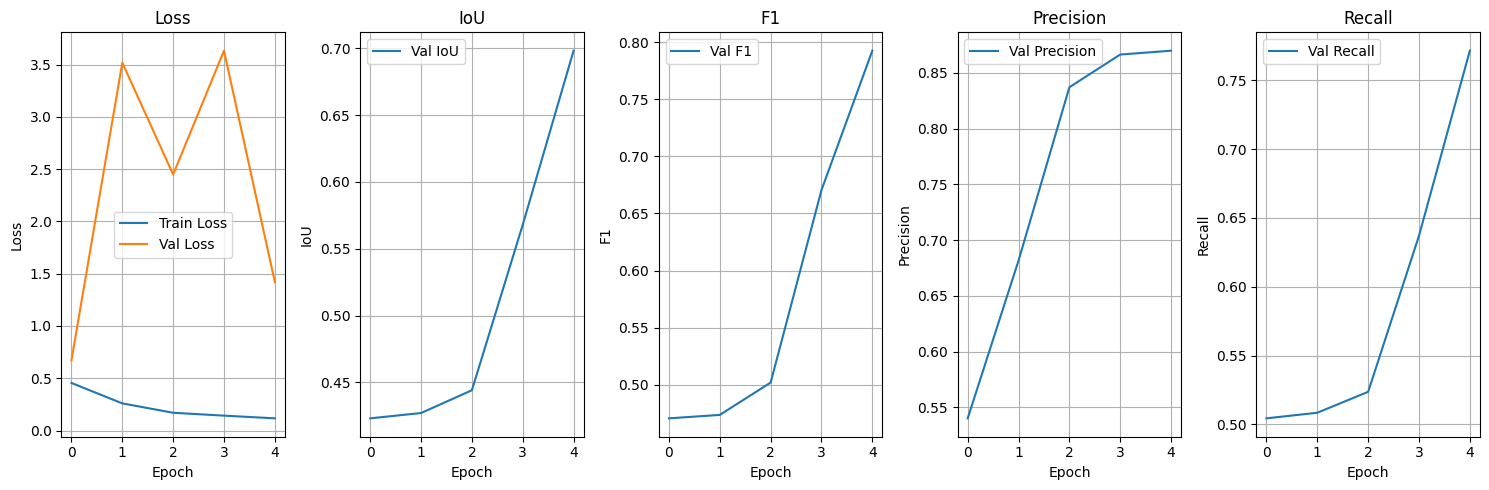


=== Performance Metrics Summary ===
IoU     - Best: 0.6981 | Final: 0.6981
F1      - Best: 0.7926 | Final: 0.7926
Precision - Best: 0.8697 | Final: 0.8697
Recall  - Best: 0.7714 | Final: 0.7714
Val Loss - Best: 0.6711 | Final: 1.4208



,epoch,train_loss,val_loss,val_iou,val_f1,val_precision,val_recall
0,1,0.454930,0.671059,0.423072,0.470482,0.540253,0.504401
1,2,0.259371,3.518580,0.427039,0.473495,0.681666,0.508468
2,3,0.169684,2.449113,0.444097,0.501837,0.836993,0.523665
3,4,0.142229,3.633370,0.567903,0.670476,0.866289,0.637021
4,5,0.116359,1.420751,0.698122,0.792564,0.869714,0.771448


In [23]:
geoai.plot_performance_metrics(
    history_path=f"{out_folder}/unet_models/training_history.pth",
    figsize=(15, 5),
    verbose=True,
)

![image](https://github.com/user-attachments/assets/9355446f-f9ba-4818-aedb-4bb5dee56813)

## Performance Metrics

**IoU (Intersection over Union)** and **Dice score** are both popular metrics used to evaluate the similarity between two binary masks—often in image segmentation tasks. While they are related, they are not the same.

---

### 🔸 **Definitions**

#### **IoU (Jaccard Index)**

$$
\text{IoU} = \frac{|A \cap B|}{|A \cup B|}
$$

* Measures the overlap between predicted region $A$ and ground truth region $B$ relative to their union.
* Ranges from 0 (no overlap) to 1 (perfect overlap).

#### **Dice Score (F1 Score for Sets)**

$$
\text{Dice} = \frac{2|A \cap B|}{|A| + |B|}
$$

* Measures the overlap between $A$ and $B$, but gives more weight to the intersection.
* Also ranges from 0 to 1.

---

### 🔸 **Key Differences**

| Metric   | Formula                     | Penalizes                      | Sensitivity                      |
| -------- | --------------------------- | ------------------------------ | -------------------------------- |
| **IoU**  | $\frac{TP}{TP + FP + FN}$   | FP and FN equally              | Less sensitive to small objects  |
| **Dice** | $\frac{2TP}{2TP + FP + FN}$ | Less harsh on small mismatches | More sensitive to small overlaps |

> TP: True Positive, FP: False Positive, FN: False Negative

---

### 🔸 **Relationship**

Dice and IoU are mathematically related:

$$
\text{Dice} = \frac{2 \cdot \text{IoU}}{1 + \text{IoU}} \quad \text{or} \quad \text{IoU} = \frac{\text{Dice}}{2 - \text{Dice}}
$$

---

### 🔸 **When to Use What**

* **IoU**: Common in object detection and semantic segmentation benchmarks (e.g., COCO, Pascal VOC).
* **Dice**: Preferred in medical imaging and when class imbalance is an issue, due to its sensitivity to small regions.

In [24]:
import numpy as np
import geopandas as gpd
import pandas as pd
import rasterio, rasterio.mask
from shapely.geometry import box
from pathlib import Path

# --- paths (edit if needed)
TEST_RASTER = "naip_test.tif"                          # NAIP, 4 bands [R,G,B,NIR]
PRED_VECTOR = "naip_test_semantic_prediction.geojson"  # from your vectorize step
OUT_DIR = Path("geoai_diagnostics")
OUT_DIR.mkdir(exist_ok=True)


In [25]:
# Load predicted polygons
bld = gpd.read_file(PRED_VECTOR)
if "area_m2" not in bld.columns:
    bld["area_m2"] = bld.geometry.area

# Optional: filter tiny artifacts (keep your threshold if you already did)
bld = bld[bld["area_m2"] > 50].copy()
bld = bld.reset_index(drop=True)
print(f"Predicted buildings kept: {len(bld)}")


Predicted buildings kept: 616


In [26]:
CELL_M = 200  # grid cell size in meters (tunable)

with rasterio.open(TEST_RASTER) as src:
    crs = src.crs
    bounds = src.bounds

xmin, ymin, xmax, ymax = bounds.left, bounds.bottom, bounds.right, bounds.top
xs = np.arange(xmin, xmax, CELL_M)
ys = np.arange(ymin, ymax, CELL_M)

cells = [box(x0, y0, x0 + CELL_M, y0 + CELL_M) for x0 in xs for y0 in ys]
grid = gpd.GeoDataFrame({"cell_id": range(len(cells))}, geometry=cells, crs=crs)
grid_area_m2 = CELL_M * CELL_M
grid.head()


,cell_id,geometry
0,0,"POLYGON ((454841.6 5276774.4, 454841.6 5276974..."
1,1,"POLYGON ((454841.6 5276974.4, 454841.6 5277174..."
2,2,"POLYGON ((454841.6 5277174.4, 454841.6 5277374..."
3,3,"POLYGON ((454841.6 5277374.4, 454841.6 5277574..."
4,4,"POLYGON ((454841.6 5277574.4, 454841.6 5277774..."


In [27]:
def ndvi_mean_for_geom(geom):
    with rasterio.open(TEST_RASTER) as src:
        try:
            out, _ = rasterio.mask.mask(src, [geom.__geo_interface__], crop=True)
            # NAIP typical order: [R,G,B,NIR]
            R = out[0].astype(np.float32)
            N = out[3].astype(np.float32)
            mask = (R + N) > 0
            if mask.sum() == 0:
                return np.nan
            ndvi = (N - R) / (N + R + 1e-6)
            return float(np.nanmean(np.where(mask, ndvi, np.nan)))
        except Exception:
            return np.nan

ndvi_vals = [ndvi_mean_for_geom(g) for g in grid.geometry]
grid["ndvi_mean"] = ndvi_vals
# quick “green ratio” proxy: 1 if a cell is generally green, else 0 (tune threshold)
grid["green_flag"] = (grid["ndvi_mean"] > 0.3).astype(float)


In [28]:
# Spatial join for count and size stats
sj = gpd.sjoin(bld[["geometry","area_m2"]], grid[["cell_id","geometry"]], predicate="intersects")
agg = sj.groupby("cell_id").agg(
    bld_count=("area_m2", "size"),
    bld_area_sum=("area_m2", "sum"),
    mean_bld_area=("area_m2", "mean"),
    med_bld_area=("area_m2", "median")
)

grid = grid.join(agg, on="cell_id")
grid[["bld_count","bld_area_sum","mean_bld_area","med_bld_area"]] = \
    grid[["bld_count","bld_area_sum","mean_bld_area","med_bld_area"]].fillna(0)

grid["bld_coverage"] = grid["bld_area_sum"] / grid_area_m2  # fraction of cell covered by buildings

# Optional compactness/fragmentation proxy: many small buildings → fragmented fabric
grid["pct_small_structures"] = 0.0
if len(sj) > 0:
    small = sj[sj["area_m2"] < 60].groupby("cell_id").size()
    grid.loc[small.index, "pct_small_structures"] = (small / grid["bld_count"]).fillna(0).loc[small.index]


In [30]:
def minmax(s):
    if np.nanmax(s) == np.nanmin(s):
        return s*0
    return (s - np.nanmin(s)) / (np.nanmax(s) - np.nanmin(s))

# helpers, normalized
grid["_n_bld"]     = minmax(grid["bld_count"])
grid["_small"]     = minmax(grid["pct_small_structures"])
grid["_cov"]       = minmax(grid["bld_coverage"])
grid["_inv_ndvi"]  = 1 - minmax(grid["ndvi_mean"].fillna(0))

# Sprawl score: many buildings, many small ones, moderate/low coverage (leapfrog/fragmentation)
grid["sprawl_score"] = (0.45*grid["_n_bld"] + 0.45*grid["_small"] + 0.10*(1 - grid["_cov"])).clip(0,1)

# Environmental degradation: low NDVI + high building coverage (as an impervious proxy)
grid["envdeg_score"] = (0.6*grid["_inv_ndvi"] + 0.4*grid["_cov"]).clip(0,1)


In [32]:
def recommend(row):
    recs = []

    # Sprawl + low greenness → consolidation + green protection
    if row["sprawl_score"] >= 0.6 and row["ndvi_mean"] < 0.3:
        recs += [
            "Infill & gentle densification near services (form-based code).",
            "Protect peri-urban green wedges; set urban growth boundaries.",
            "Complete sidewalks + crossings; create mixed-use nodes."
        ]
    elif row["sprawl_score"] >= 0.6:
        recs += [
            "Cluster development; curb leapfrog subdivisions.",
            "Improve block connectivity; add missing street links."
        ]

    # Environmental degradation → blue-green retrofits
    if row["envdeg_score"] >= 0.6 and row["ndvi_mean"] < 0.3:
        recs += [
            "Street-tree program & pocket parks for cooling and amenity.",
            "Bioswales / rain gardens; permeable parking retrofits.",
            "Prioritize grey-to-green conversions on public land."
        ]

    # Always suggest low-regret monitoring where signals are mild
    if not recs:
        return "Monitor; no immediate action (track NDVI and coverage quarterly)."
    # de-duplicate while keeping order
    seen, out = set(), []
    for r in recs:
        if r not in seen:
            out.append(r); seen.add(r)
    return "; ".join(out)

grid["recommendations"] = grid.apply(recommend, axis=1)


In [33]:
gj = OUT_DIR / "urban_diagnostics.geojson"
csv = OUT_DIR / "urban_diagnostics.csv"

cols = ["cell_id","sprawl_score","envdeg_score","bld_count","bld_coverage",
        "mean_bld_area","med_bld_area","pct_small_structures","ndvi_mean","recommendations"]

grid.to_file(gj, driver="GeoJSON")
grid[cols].to_csv(csv, index=False)

print(" Exports written:")
print(" •", gj)
print(" •", csv)


✅ Exports written:
 • geoai_diagnostics/urban_diagnostics.geojson
 • geoai_diagnostics/urban_diagnostics.csv


In [35]:
import leafmap
m = leafmap.Map()
m.add_raster(TEST_RASTER, layer_name="NAIP")
m.add_geojson(str(OUT_DIR/"urban_diagnostics.geojson"), layer_name="Diagnostics grid")
m


Map(center=[47.6464835, -117.59043650000001], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom…